# Introducción a la Ciencia de Datos: Tarea 1

Este notebook contiene el código de base para realizar la Tarea 1 del curso. Puede copiarlo en su propio repositorio y trabajar sobre el mismo.
Las **instrucciones para ejecutar el notebook** están en la [página inicial del repositorio](https://gitlab.fing.edu.uy/maestria-cdaa/intro-cd).

Se utiliza el lenguaje Python y la librería Pandas. Si no tiene ninguna familiaridad con la librería, se recomienda realizar algún tutorial introductorio (ver debajo).
También se espera que los alumnos sean proactivos a la hora de consultar las documentaciones de las librerías y del lenguaje, para entender el código provisto.
Además de los recursos provistos en la [página del curso](https://eva.fing.edu.uy/course/view.php?id=1378&section=1), los siguientes recursos le pueden resultar interesantes:
 - [Pandas getting started](https://pandas.pydata.org/docs/getting_started/index.html#getting-started) y [10 minutes to pandas](https://pandas.pydata.org/docs/user_guide/10min.html): Son parte de la documentación en la página oficial de Pandas.
 - [Kaggle Learn](https://www.kaggle.com/learn): Incluye tutoriales de Python y Pandas.


Si desea utilizar el lenguaje R y está dispuesto a no utilizar (o traducir) este código de base, también puede hacerlo.

En cualquier caso, **se espera que no sea necesario revisar el código para corregir la tarea**, ya que todos los resultados y análisis relevantes deberían estar en el **informe en formato PDF**.

## Cargar bibliotecas (dependencias)
Recuerde instalar los requerimientos (`requirements.txt`) en el mismo entorno donde está ejecutando este notebook (ver [README](https://github.com/DonBraulio/introCD)).

In [2]:
from time import time
from pathlib import Path
import re
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
from datasets import load_dataset

import nltk
try:
    from nltk.corpus import stopwords
    stopwords.words("english")
except LookupError:
    nltk.download("stopwords")
    from nltk.corpus import stopwords

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110

## Descarga del dataset
En esta tarea se utilizará una base de datos abierta que contiene artículos de noticias publicados en distintos medios de prensa, con la finalidad de realizar una clasificación de textos según el medio de prensa al que pertenecen. [Link](https://huggingface.co/datasets/rjac/all-the-news-2-1-Component-one?utm_source=chatgpt.com) \
\
Ejecute la siguiente celda para descargar los datos y cargarlos en un dataframe de pandas. La constante `DATA_PATH` determina la ubicación donde se almacenaran los datos.

In [3]:
ds = load_dataset("tomas-gr/all-the-news-2-1-Component-one-sampled", split="train",cache_dir="../data")
df = ds.to_pandas()

## Lectura de Datos

In [4]:
# Veamos las primeras filas del DataFrame
df.head()

,idx,article_idx,date,year,month,day,author,title,article,url,section,publication
0,1,1,2018-02-02,2018,2.0,2,NaN,BRIEF-Teva Says Fremanezumab Marketing Authori...,Feb 2 (Reuters) - Teva Pharmaceutical Industri...,https://www.reuters.com/article/brief-teva-say...,Healthcare,Reuters
1,2,2,2018-05-01,2018,5.0,1,NaN,CMS' Verma says it’s time health care caught u...,The head of the Centers for Medicare and Medic...,https://www.cnbc.com/2018/04/30/cms-verma-says...,Health and Science,CNBC
2,3,3,2017-08-14,2017,8.0,14,Harper Neidig,Uber investor accuses Kalanick of 'undermining...,"Benchmark, the venture capital firm that helpe...",https://thehill.com/policy/technology/346520-u...,NaN,The Hill
3,4,4,2017-04-03 00:00:00,2017,4.0,3,NaN,Chad Johnson Catches Uno Touchdown In Mexican ...,VIVA OCHOCINCO!!!!! Chad Johnson made his triu...,https://www.tmz.com/2017/04/03/chad-johnson-me...,NaN,TMZ
4,5,5,2018-12-27 19:20:08,2018,12.0,27,Aja Romano,"Hopepunk, explained: the storytelling trend th...",Literary and artistic movements often arise sp...,https://www.vox.com/2018/12/27/18137571/what-i...,NaN,Vox


In [5]:
# Veamos información general del DataFrame
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 30213 entries, 0 to 30212
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   idx          30213 non-null  int64
 1   article_idx  30213 non-null  int64
 2   date         30213 non-null  str  
 3   year         30213 non-null  str  
 4   month        30213 non-null  str  
 5   day          30213 non-null  str  
 6   author       18808 non-null  str  
 7   title        30213 non-null  str  
 8   article      29037 non-null  str  
 9   url          30072 non-null  str  
 10  section      19981 non-null  str  
 11  publication  30072 non-null  str  
dtypes: int64(2), str(10)
memory usage: 96.1 MB


# Parte 1: Cargado y Limpieza de Datos

## A. Exploración de Datos
Analice el contenido del DataFrame. Reporte si existen datos faltantes en algún campo, o cualquier otro problema de calidad de datos que encuentre. \
En particular, analice la cantidad de artículos por medio de prensa, y a partir de este punto trabaje con los **cinco medios con mayor cantidad de artículos**.

In [6]:
# Analizamos datos faltantes por columna
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_summary = pd.DataFrame({
    "missing_count": missing,
    "missing_pct": missing_pct,
}).sort_values("missing_pct", ascending=False)

missing_summary[missing_summary["missing_count"] > 0]

,missing_count,missing_pct
author,11405,37.75
section,10232,33.87
article,1176,3.89
url,141,0.47
publication,141,0.47


`author` y `section` tienen alrededor de un tercio de faltantes. No se usan como variable, así que no se imputan, rellenarlas a mano introduciría sesgo. `article` tiene 3,89% de faltantes y se reemplaza por un string vacío en la limpieza para conservar el título. Los 141 registros sin `publication` (0,47%) se eliminan al filtrar por los cinco medios principales.

In [7]:
# Cantidad de artículos por medio (top 5)
top5_counts = df["publication"].value_counts().head(5)
print("Top 5 publicaciones:")
print(top5_counts.to_string())

# Guardamos el listado de los cinco medios como constante para el resto del notebook
TOP5 = top5_counts.index.tolist()
print("\nLista TOP5:", TOP5)

Top 5 publicaciones:
publication
Reuters               9431
The New York Times    2840
CNBC                  2623
The Hill              2349
People                1528

Lista TOP5: ['Reuters', 'The New York Times', 'CNBC', 'The Hill', 'People']


Quedan 18.771 artículos en el top 5. La distribución es desbalanceada: Reuters tiene 9.431 artículos (49,7%), People 1.528 (8,1%).

**Tipos de datos**

Las columnas temporales (`date`, `year`, `month`, `day`) están guardadas como cadenas. `date` además tiene formatos inconsistentes (`2018-02-02` y `2017-04-03 00:00:00`). Se convierten con `pd.to_datetime(date, format='mixed', errors='coerce')` y ninguna fila queda como `NaT`.

## B. Visualización temporal
Genere una gráfica que permita visualizar los artículos de los cinco medios a lo largo del tiempo, con alguna escala temporal adecuada. \
Comente si se identifican momentos de mayor actividad o patrones temporales en la cobertura.

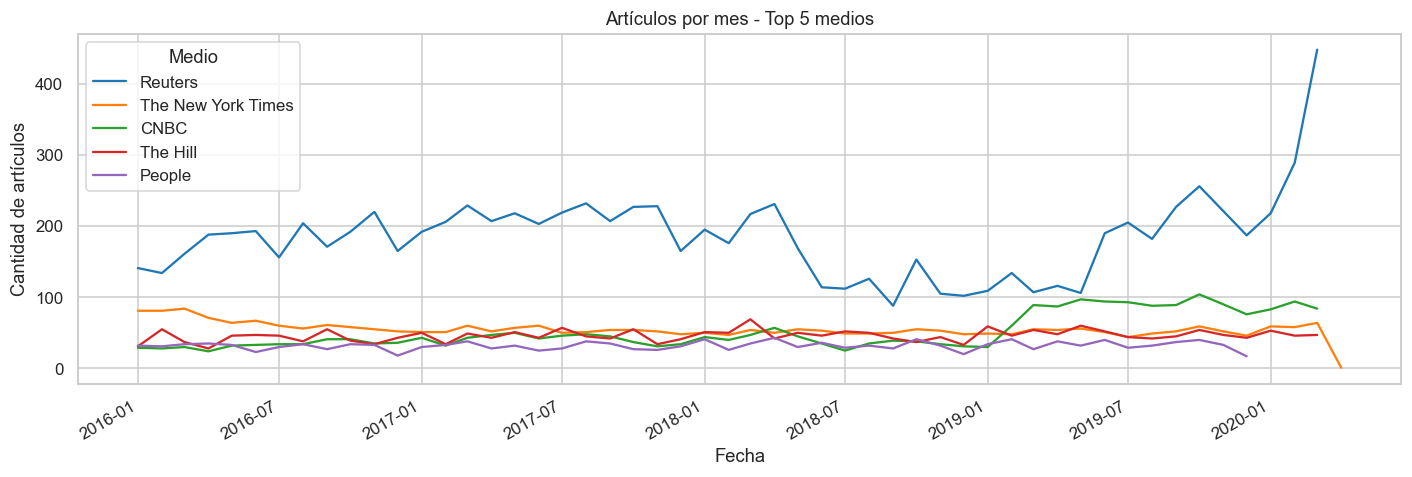

In [8]:
df_top5 = df[df["publication"].isin(TOP5)].copy()
df_top5["date_parsed"] = pd.to_datetime(df_top5["date"], format="mixed", errors="coerce")
df_top5["year_month"] = df_top5["date_parsed"].dt.to_period("M")

monthly_counts = (
    df_top5.groupby(["year_month", "publication"])
    .size()
    .reset_index(name="count")
)
monthly_counts["year_month_dt"] = monthly_counts["year_month"].dt.to_timestamp()

fig, ax = plt.subplots(figsize=(13, 4.5))
palette = sns.color_palette("tab10", n_colors=len(TOP5))
for pub, color in zip(TOP5, palette):
    subset = monthly_counts[monthly_counts["publication"] == pub]
    ax.plot(subset["year_month_dt"], subset["count"], label=pub, linewidth=1.5, color=color)

ax.set_title("Artículos por mes - Top 5 medios")
ax.set_xlabel("Fecha")
ax.set_ylabel("Cantidad de artículos")
ax.legend(title="Medio")
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

NYT, The Hill, CNBC y People oscilan entre 30 y 70 artículos por mes durante todo el período. Reuters está claramente por encima, entre 150 y 250 mensuales.

El pico más claro es Reuters en marzo y abril de 2020, que pasa de unos 200 artículos por mes a cerca de 450, coincidente con el inicio de la pandemia. Antes hay una caída de Reuters en julio y agosto de 2018 (de ~230 a ~100 artículos por mes) sin explicación a primera vista, probablemente un sesgo de muestreo del subconjunto. CNBC crece de forma sostenida.

## C. Limpieza de texto y conteo de palabras
Se provee la función `clean_text(...)` que realiza parte de la normalización del texto. \
**Complete la función** agregando signos de puntuación faltantes y cualquier otra normalización que considere oportuna. \
Compruebe el resultado observando el contenido del DataFrame procesado. Comente todas las transformaciones que haya agregado y justifique.

In [18]:
# Mapeo de caracteres tipográficos no-ASCII frecuentes (comillas curvas, guiones largos, ...)
COMILLAS_Y_GUIONES = {
    "‘": " ", "’": " ",   # comillas simples curvas
    "“": " ", "”": " ",   # comillas dobles curvas
    "–": " ", "—": " ",   # en-dash y em-dash
    "…": " ",                  # elipsis
    "\xa0": " ",                    # NBSP
}

# Puntuación ASCII a reemplazar por espacio
PUNTUACION = [
    "[", "]", "{", "}", "(", ")",
    ",", ":", ";", ".", "?", "!", "¡", "¿",
    "\"", "'", "`",
    "-", "/", "\\", "|", "*", "&", "%", "$", "#", "@",
    "<", ">", "=", "+", "~", "^",
]


def clean_text(df, column_name):
    """Normaliza una columna de texto para conteo de palabras.

    Pasos:
      1. Pasar a minúsculas.
      2. Reemplazar URLs por espacio.
      3. Normalizar tipografía no-ASCII.
      4. Quitar signos de puntuación.
      5. Quitar dígitos (no aportan al conteo léxico).
      6. Colapsar espacios múltiples.
    """
    s = df[column_name].fillna("").astype(str)

    # 1. Minúsculas
    s = s.str.lower()

    # 2. URLs
    s = s.str.replace(r"https?://\S+|www\.\S+", " ", regex=True)

    # 3. Tipografía no-ASCII
    for src, dst in COMILLAS_Y_GUIONES.items():
        s = s.str.replace(src, dst, regex=False)

    # 4. Puntuación
    for p in PUNTUACION:
        s = s.str.replace(p, " ", regex=False)

    # 5. Dígitos
    s = s.str.replace(r"\d+", " ", regex=True)

    # 6. Espacios redundantes
    s = s.str.replace(r"\s+", " ", regex=True).str.strip()

    return s

In [22]:
import textwrap
print()

# Trabajamos sobre título + cuerpo (ver sección D del informe)
df_top5["FullText"] = (
    df_top5["title"].fillna("").astype(str) + ". " +
    df_top5["article"].fillna("").astype(str)
)

df_top5["CleanText"] = clean_text(df_top5, "FullText")

# Sanity check: comparamos un artículo antes y después
print("ANTES:")
id = 4


print(textwrap.fill(df_top5["FullText"].iloc[id], width=180))
print("\nDESPUÉS:")
print(textwrap.fill(df_top5["CleanText"].iloc[id], width=180))


ANTES:
Bank of Montreal's quarterly earnings beat market forecasts. TORONTO, Dec 4 (Reuters) - Bank of Montreal on Tuesday reported a 19 percent increase in fourth quarter earnings,
beating market forecasts, helped by a strong performance at its retail and wealth management businesses. Canada’s fourth-biggest lender reported fourth-quarter earnings, excluding
one-off items, of C$2.32 per share, compared with C$1.94 a year ago. Analysts had forecast earnings of C$2.29, according to IBES data from Refinitiv. (Reporting by Matt Scuffham;
Editing by Kirsten Donovan)

DESPUÉS:
bank of montreal s quarterly earnings beat market forecasts toronto dec reuters bank of montreal on tuesday reported a percent increase in fourth quarter earnings beating market
forecasts helped by a strong performance at its retail and wealth management businesses canada s fourth biggest lender reported fourth quarter earnings excluding one off items of c
per share compared with c a year ago analysts had forecast ea

## D. Elección de campos de texto
Discuta si conviene trabajar con:
- sólo el cuerpo del artículo,
- sólo el título,
- o una combinación de ambos.

Justifique brevemente su decisión.

Las tres opciones:

- *Sólo cuerpo*: máximo volumen léxico, pero el 3,89% de artículos sin `article` queda sin texto.
- *Sólo título*: poca evidencia por artículo para diferencias léxicas finas.
- *Cuerpo más título*: conserva los artículos sin cuerpo (queda el título) y suma señal.

Se trabaja sobre `title + ". " + article`. El punto y el espacio se eliminan en la limpieza, así que no afectan el conteo.

## E. Pistas que identifican al medio de prensa
Analice si en el texto aparecen pistas que identifiquen de manera directa al medio de prensa (nombres del medio, URLs, firmas, nombres de secciones, plantillas repetidas, etc.). \
En caso de encontrarlas, comente si considera conveniente eliminarlas o reducir su impacto, y justifique su decisión.

In [10]:
# Patrones identificadores por medio (nombre, dominios, firmas)
PISTAS = {
    "Reuters": [r"\breuters\b", r"\(reuters\)", r"thomson reuters", r"reporting by"],
    "The New York Times": [r"\bnew york times\b", r"\bnytimes\b", r"\bn\.y\. times\b"],
    "CNBC": [r"\bcnbc\b"],
    "The Hill": [r"\bthe hill\b", r"thehill\.com"],
    "People": [r"\bpeople magazine\b", r"people\.com"],
}

filas = []
for pub, sub in df_top5.groupby("publication"):
    for pista_de_pub, patrones in PISTAS.items():
        apariciones = 0
        articulos_con_pista = 0
        for art in sub["FullText"].fillna(""):
            texto = art.lower()
            c = sum(len(re.findall(p, texto)) for p in patrones)
            apariciones += c
            if c > 0:
                articulos_con_pista += 1
        filas.append({
            "medio": pub,
            "pista_de": pista_de_pub,
            "apariciones": apariciones,
            "articulos_con_pista": articulos_con_pista,
            "n_articulos": len(sub),
            "pct_articulos": round(100 * articulos_con_pista / len(sub), 1),
        })

df_pistas = pd.DataFrame(filas)

# Mostramos sólo cuando la pista coincide con el propio medio (auto-identificación)
df_pistas[df_pistas["medio"] == df_pistas["pista_de"]].sort_values("pct_articulos", ascending=False)

,medio,pista_de,apariciones,articulos_con_pista,n_articulos,pct_articulos
18,The Hill,The Hill,3677,2335,2349,99.4
10,Reuters,Reuters,27291,8763,9431,92.9
2,CNBC,CNBC,1832,907,2623,34.6
21,The New York Times,The New York Times,1156,646,2840,22.7
9,People,People,58,51,1528,3.3


99,4% de los artículos de The Hill y 92,9% de los de Reuters mencionan al propio medio. La razón es estructural: vienen de las firmas (`(Reuters)`, `Reporting by ...`) y estructura de cómo cierran el artículo. CNBC y NYT también tienen un gran porcentaje (34,6% y 22,7%), People apenas 3,3%.

En 2.A esto reaparece como *reuters*, *reporting*, *editing* en el top de Reuters y *hill*, *thehill* en el de The Hill.

## F. Restricción por sección o período temporal
Evalúe si conviene restringir el análisis a artículos de una misma sección temática o de un período temporal acotado, con el objetivo de reducir el efecto del tema sobre una futura tarea de clasificación por medio. \
No es necesario implementar esta restricción, pero sí discutir sus posibles ventajas y desventajas.

Restringir el análisis ayudaría a aislar las diferencias de estilo del efecto del tema (que People se distinga porque "escribe distinto" y no sólo porque "cubre celebridades"). Las dos opciones tienen problemas.

*Por sección*: `section` tiene 33,87% de faltantes y las etiquetas no son comparables entre medios (Reuters etiqueta *Healthcare*, CNBC *Health and Science*). Habría que mapear taxonomías a mano antes de cualquier filtro.

*Por período*: es más simple. La serie de 1.B sugiere quedarse en 2017-2019 y dejar fuera el pico de la pandemia en Reuters en 2020 y la cola incompleta del dataset. Se pierde volumen y, además, el período más interesante.

# Parte 2: Conteo de Palabras y Visualizaciones

## A. Palabras más frecuentes por medio
Realice una visualización que permita comparar las palabras más frecuentes de cada uno de los cinco medios de prensa. \
Sin necesidad de implementarlo, proponga ideas para modificar esta visualización con el fin de encontrar diferencias entre secciones temáticas, fechas, o tipos de noticias.

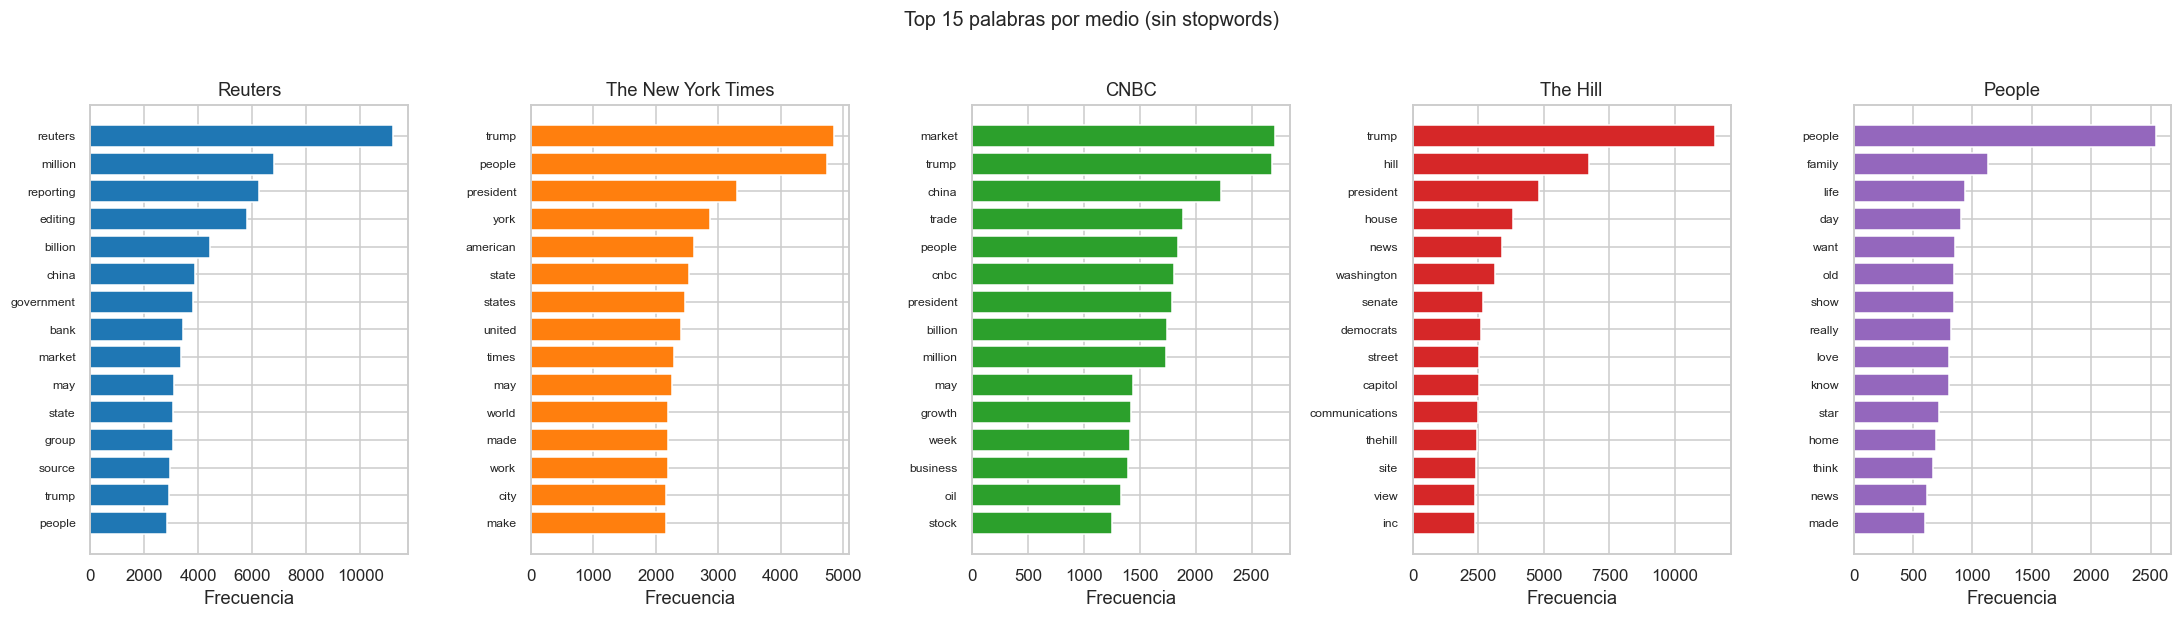

In [11]:
# Stopwords: las del idioma inglés más un pequeño set para periodismo.
# Nota: no incluimos "people" porque es el nombre del medio People y es señal.
STOPWORDS_EN = set(stopwords.words("english"))
STOPWORDS_EXTRA = {
    "said", "would", "could", "also", "one", "two", "three", "first",
    "last", "year", "years", "new", "time", "going", "get",
    "go", "back", "still", "much", "many", "even", "like", "us", "u",
    "say", "says", "told", "tell", "according", "company", "companies",
    "percent", "since",
    # tokens-residuo de contracciones
    "s", "t", "re", "ve", "ll", "d", "m",
}
STOPWORDS = STOPWORDS_EN | STOPWORDS_EXTRA


def tokenizar(texto):
    return [tok for tok in texto.split() if len(tok) > 2 and tok not in STOPWORDS]


# Top 15 palabras por medio
top_palabras_por_medio = {}
for pub, sub in df_top5.groupby("publication"):
    contador = Counter()
    for txt in sub["CleanText"].fillna(""):
        contador.update(tokenizar(txt))
    top_palabras_por_medio[pub] = contador.most_common(15)

# Visualización: una barra horizontal por medio
fig, axes = plt.subplots(1, 5, figsize=(20, 5.5))
palette = sns.color_palette("tab10", n_colors=5)
for ax, pub, color in zip(axes, TOP5, palette):
    pares = top_palabras_por_medio[pub]
    palabras = [p for p, _ in pares][::-1]
    cuentas = [c for _, c in pares][::-1]
    ax.barh(palabras, cuentas, color=color)
    ax.set_title(pub)
    ax.set_xlabel("Frecuencia")
    ax.tick_params(axis="y", labelsize=8)

fig.suptitle("Top 15 palabras por medio (sin stopwords)", y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

# Problemas observados:
# - Tokens del nombre del medio dominan (reuters, hill, cnbc, york, times) -> ver 1.E
# - 'reporting', 'editing' en Reuters son parte del boilerplate de firmas
# - 'inc', 'street' en The Hill provienen del footer del medio
# Ideas de mejora: TF-IDF, segmentar por sección/fecha, usar bigramas (white house, wall street).

Diferencias temáticas: vocabulario económico en CNBC y Reuters (*market*, *trade*, *billion*), político en The Hill y NYT (*trump*, *president*, *house*, *senate*), entretenimiento y vida personal en People (*family*, *life*, *love*, *star*). En paralelo, las pistas de 1.E reaparecen en los rankings: *reuters*, *reporting*, *editing* en Reuters, *hill*, *thehill* en The Hill, *cnbc* en CNBC, *york*, *times* en NYT, *people* encabezando People.

Ideas para esta visualización:

- TF-IDF en lugar de frecuencia bruta, para resaltar palabras distintivas de un medio frente a los otros cuatro.
- Cortar por sección o por período (2018 vs 2019) para ver corrimientos de agenda.
- Bigramas y trigramas, para capturar *white house*, *wall street*, *new york times*.
- Nubes de palabras filtradas por tokens exclusivos de cada medio.

## B. Medios con mayor cantidad de palabras
Corra el código que permite encontrar los medios con mayor cantidad de palabras. \
En caso de encontrar algún problema luego de realizar la visualización, comente a qué se debe y proponga formas de resolverlo.

                    total_palabras  n_articulos  promedio
publication                                              
The New York Times         2623472         2840       924
Reuters                    2606519         9431       276
The Hill                   1373555         2349       585
CNBC                       1240543         2623       473
People                      649707         1528       425


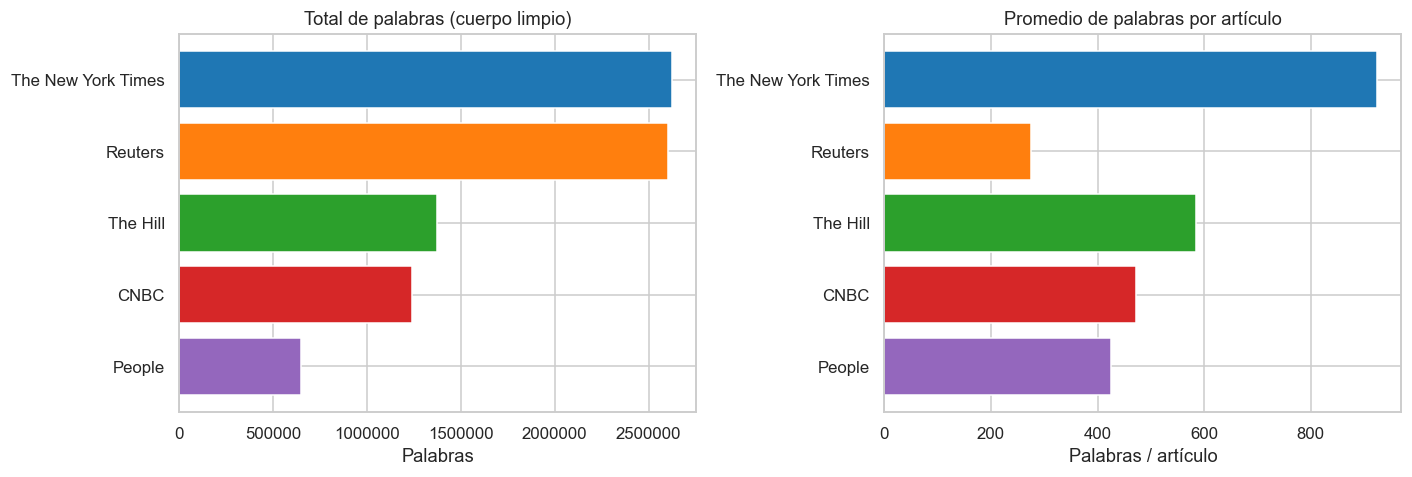

In [12]:
# Medios con mayor cantidad de palabras + promedio por artículo
df_top5["n_palabras"] = df_top5["CleanText"].fillna("").str.split().str.len()
palabras_por_medio = (
    df_top5.groupby("publication")
    .agg(total_palabras=("n_palabras", "sum"),
         n_articulos=("n_palabras", "size"),
         promedio=("n_palabras", "mean"))
    .sort_values("total_palabras", ascending=False)
)
palabras_por_medio["promedio"] = palabras_por_medio["promedio"].round(0).astype(int)
print(palabras_por_medio)

# Doble visualización: total y promedio por artículo
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
medios = palabras_por_medio.index.tolist()
palette = sns.color_palette("tab10", n_colors=len(medios))

axes[0].barh(medios, palabras_por_medio["total_palabras"], color=palette)
axes[0].invert_yaxis()
axes[0].set_title("Total de palabras (cuerpo limpio)")
axes[0].set_xlabel("Palabras")
axes[0].ticklabel_format(style="plain", axis="x")

axes[1].barh(medios, palabras_por_medio["promedio"], color=palette)
axes[1].invert_yaxis()
axes[1].set_title("Promedio de palabras por artículo")
axes[1].set_xlabel("Palabras / artículo")

plt.tight_layout()
plt.show()

# El total puede engañar: NYT y Reuters quedan empatados (~2.6M) pero por razones opuestas
# (NYT: pocos artículos largos; Reuters: muchos artículos cortos de cable). El promedio lo
# aclara: Reuters tiene 276 palabras por artículo, NYT 924.

NYT y Reuters empatan en total (~2,6 millones de palabras) por razones opuestas: NYT son pocos artículos largos (924 palabras de promedio) y Reuters son muchos cortos (276). El total por sí solo sugiere volumen comparable y eso engaña. Por eso el gráfico de arriba muestra total y promedio por artículo en paneles distintos.

## C. Matriz de menciones entre medios
Construya una matriz de 5×5, donde cada fila y columna corresponden a un medio de prensa, y la entrada (i,j) contiene la cantidad de veces que el medio *i* menciona al medio *j*. \
\
**Opcional:** genere un grafo dirigido con esa matriz de adyacencia para visualizar las menciones. Puede ser útil la biblioteca `networkx`.

                    Reuters  The New York Times  CNBC  The Hill  People
Reuters               11674                  42    45         2       5
The New York Times       54                1151    19        18       1
CNBC                   1200                  61  1791         6       1
The Hill                123                 191    20      3658       0
People                    7                  59     5         4      53


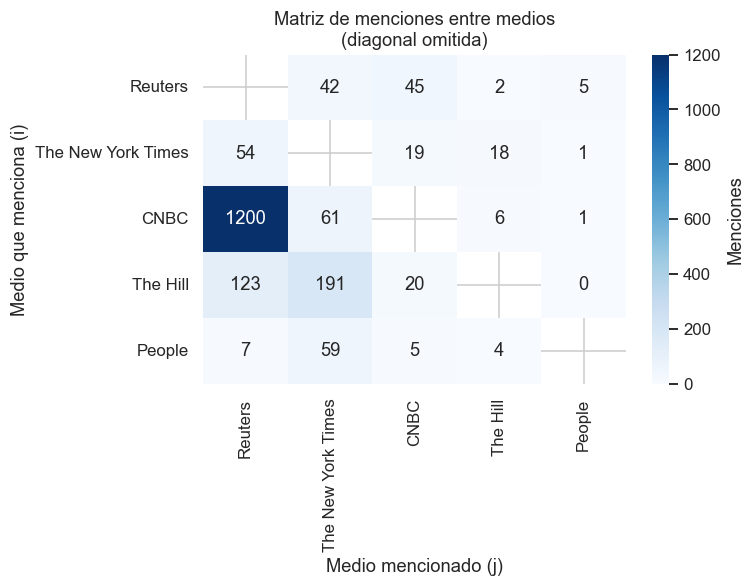

In [23]:
# Patrones para detectar la mención de cada medio en el cuerpo
PATRONES_MENCION = {
    "Reuters": [r"\breuters\b"],
    "The New York Times": [r"\bnew york times\b", r"\bnytimes\b"],
    "CNBC": [r"\bcnbc\b"],
    "The Hill": [r"\bthe hill\b", r"thehill\.com"],
    "People": [r"\bpeople magazine\b", r"\bpeople\.com\b"],
}

# Matriz: el medio i menciona al medio j
mentions_matrix = pd.DataFrame(0, index=TOP5, columns=TOP5, dtype=int)

for medio_i, sub in df_top5.groupby("publication"):
    textos = sub["article"].fillna("").str.lower().tolist()
    for medio_j, patrones in PATRONES_MENCION.items():
        total = 0
        for txt in textos:
            for p in patrones:
                total += len(re.findall(p, txt))
        mentions_matrix.loc[medio_i, medio_j] = total

print(mentions_matrix)

# Heatmap: omitimos la diagonal (auto-menciones por boilerplate)
M_plot = mentions_matrix.astype(float).to_numpy().copy()
np.fill_diagonal(M_plot, np.nan)
M_plot = pd.DataFrame(M_plot, index=mentions_matrix.index, columns=mentions_matrix.columns)

fig, ax = plt.subplots(figsize=(7, 5.5))
sns.heatmap(M_plot, annot=True, fmt=".0f", cmap="Blues",
            cbar_kws={"label": "Menciones"}, ax=ax)
ax.set_xlabel("Medio mencionado (j)")
ax.set_ylabel("Medio que menciona (i)")
ax.set_title("Matriz de menciones entre medios\n(diagonal omitida)")
plt.tight_layout()
plt.show()

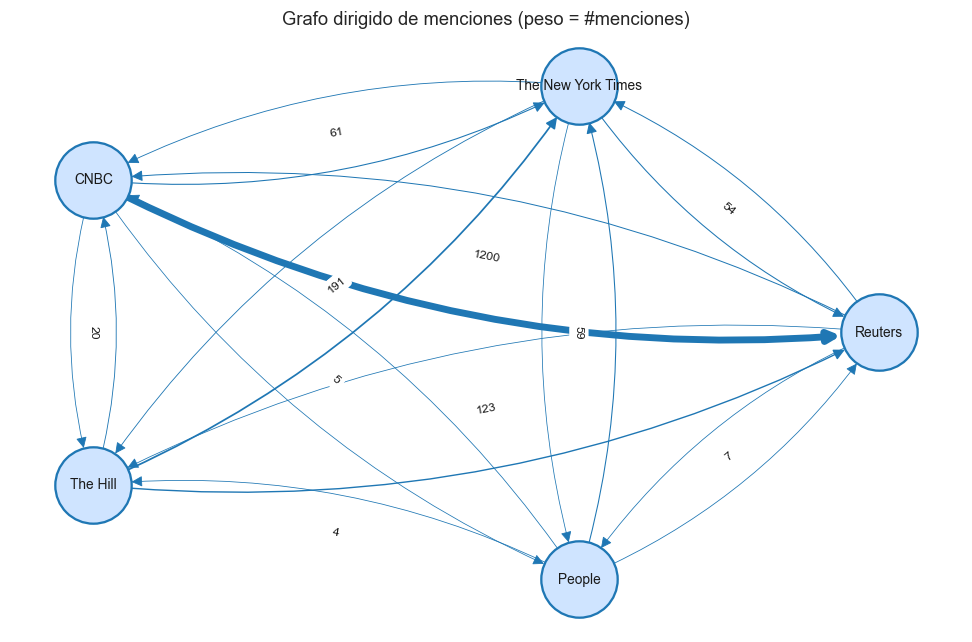

In [14]:
# Grafo dirigido de menciones (excluimos auto-loops)
G = nx.DiGraph()
for medio in mentions_matrix.index:
    G.add_node(medio)
for i in mentions_matrix.index:
    for j in mentions_matrix.columns:
        if i == j:
            continue
        w = int(mentions_matrix.loc[i, j])
        if w > 0:
            G.add_edge(i, j, weight=w)

fig, ax = plt.subplots(figsize=(9, 6))
pos = nx.circular_layout(G)
pesos = [G[u][v]["weight"] for u, v in G.edges()]
max_w = max(pesos) if pesos else 1
widths = [0.5 + 4 * (w / max_w) for w in pesos]

nx.draw_networkx_nodes(G, pos, node_color="#cfe4ff", node_size=2500,
                       edgecolors="#1f77b4", linewidths=1.5, ax=ax)
nx.draw_networkx_labels(G, pos, font_size=9, ax=ax)
nx.draw_networkx_edges(
    G, pos, width=widths, edge_color="#1f77b4",
    arrows=True, arrowsize=15, connectionstyle="arc3,rad=0.15",
    node_size=2500, ax=ax,
)
edge_labels = {(u, v): G[u][v]["weight"] for u, v in G.edges()}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=8, ax=ax)
ax.set_title("Grafo dirigido de menciones (peso = #menciones)")
ax.set_axis_off()
plt.tight_layout()
plt.show()

El peso más alto es CNBC hacia Reuters (1.200 menciones): CNBC reutiliza cable de la agencia. Después aparecen The Hill hacia NYT (191) y The Hill hacia Reuters (123): The Hill cubre política nacional y se apoya en los dos medios generalistas más grandes. NYT menciona a Reuters 54 veces. People aparece sólo con 59 menciones a NYT.

La métrica es léxica, no de citas formales: cuenta apariciones del nombre del medio sin distinguir cita real de mención casual. La diagonal queda saturada por las firmas y el boilerplate del propio medio.

## D. Preguntas propuestas
Proponga al menos tres preguntas que se podrían intentar responder a partir de estos datos, y mencione posibles caminos para responderlas, sin implementar nada.

**1. ¿Se puede separar a los medios en un espacio vectorial del texto?** Vectorizar los artículos con TF-IDF o embeddings preentrenados, aplicar reducción de dimensionalidad (PCA, t-SNE, UMAP) y medir la separación entre clases con métricas como *silhouette score* o Davies-Bouldin. Sirve como baseline geométrica antes de pasar a un clasificador supervisado.

**2. ¿Cuánto cae la accuracy de un clasificador del medio al remover las pistas léxicas?** Entrenar un clasificador multiclase (regresión logística, SVM lineal o gradient boosting sobre TF-IDF) en dos escenarios: con la limpieza actual y con una limpieza extra que saque nombres de medios, dominios y plantillas de firma. La diferencia de accuracy y de matriz de confusión entre los dos escenarios mide cuánto del problema estaba resolviendo el modelo por atajo léxico.

**3. ¿Las distribuciones de longitud de artículos por medio son estadísticamente distintas?** Sobre el conteo de 2.B, comparar histogramas y medianas, y aplicar un test no paramétrico (Mann-Whitney por pares o Kruskal-Wallis multiclase) para evaluar si las diferencias son atribuibles a variabilidad de muestreo.

**4. ¿Qué estructura tiene la red de menciones entre medios?** Sobre la matriz de 2.C, calcular métricas de centralidad (in-degree, out-degree, PageRank) y compararlas con un modelo nulo aleatorio (*configuration model*) para identificar qué aristas son significativas respecto al azar.